In [1]:
%pip install -e .

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Obtaining file:///home/f73aeabd-6de4-471d-92a9-1ba552ae6153/Ising_model
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ising-model (pyproject.toml) ... done
  Created wheel for ising-model: filename=ising_model-0.1.0-0.editable-py3-none-any.whl size=2183 sha256=8339cec2d5b07e28ad0d60b02fa7d8682ac13c6e6af6b6d6c9e1ab71d44396fd
  Stored in directory: /tmp/pip-ephem-wheel-cache-8upmpjv8/wheels/34/a0/68/626680e74a9b85fce267b24b9ffea0b884ce496ae9bdbfbc3a
Successfully built ising-model
  Attempting uninstall: ising-model
    Found existing installation: ising-model 0.1.0
    Uninstalling ising-model-0.1.0:
      Successfully uninstalled ising-model-0.1.0
Note: you may need to restart the kernel 

In [2]:
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

import im #local packge 

In the Dicke state

$$|D_k^N\rangle,$$

$k$ is the **number of qubits in the excited state $|1\rangle$**.

* $N$: total number of qubits
* $k$: number of $|1\rangle$ states
* $N - k$: number of $|0\rangle$ states

# All-to-All Transverse-Field Ising Model

The Hamiltonian of the **all-to-all transverse-field Ising model** is

$$
H =
J\sum_{i<j}\sigma_z^{(i)}\sigma_z^{(j)}
+
\Omega\sum_i\sigma_x^{(i)}.
$$

where:

- $H$ is the total energy operator (Hamiltonian) of the system.
- $J$ is the interaction strength between the spins.
- $\sigma_z^{(i)}\sigma_z^{(j)}$ describes the interaction between spins $i$ and $j$ along the $z$-direction.
- $\Omega$ is the strength of the external transverse field.
- $\sigma_x^{(i)}$ describes the transverse field acting on spin $i$ along the $x$-direction.
- $\sum_{i<j}$ means that every distinct pair of spins is included once.

This Hamiltonian is an important example of a **collective spin model**. A more general spin Hamiltonian may contain interactions in the $x$, $y$, and $z$ directions, with different interaction strengths.

### Important technical point

If the Hamiltonian is instead written using  $$\sum_{i\neq j},$$

then every pair is counted twice: both $(i,j)$ and $(j,i)$ are included. Therefore, a factor of $\frac{1}{2}$ is required:

$$
H =
\frac{J}{2}\sum_{i\neq j}
\sigma_z^{(i)}\sigma_z^{(j)}
+
\Omega\sum_i\sigma_x^{(i)}.
$$

The two expressions are equivalent:

$$
J\sum_{i<j}\sigma_z^{(i)}\sigma_z^{(j)}
=
\frac{J}{2}\sum_{i\neq j}
\sigma_z^{(i)}\sigma_z^{(j)}.
$$

In [3]:
# Number of spins
N = 2

# Construct all N+1 Dicke states
for k in range(N + 1):
    state = im.states.dicke_state(N, k)

    print("Numerical vector:")
    print(state)

    print("The same state in N and N see explicitly")
    print(f"|D_{k}^{N}> = {state}")
    print()

Numerical vector:
[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
The same state in N and N see explicitly
|D_0^2> = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]

Numerical vector:
[0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]
The same state in N and N see explicitly
|D_1^2> = [0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]

Numerical vector:
[0.+0.j 0.+0.j 0.+0.j 1.+0.j]
The same state in N and N see explicitly
|D_2^2> = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]



In [4]:
print("Full Hilbert-space dimension:", 2**N)
print("Symmetric Dicke-space dimension:", N + 1)

Full Hilbert-space dimension: 4
Symmetric Dicke-space dimension: 3


## Displaying the Dicke States

The function `dicke_state(N, k)` returns a Dicke state as a numerical NumPy vector. Therefore, I use the `display_state(state, N)` function to present the result in Dirac notation, making it easier to read and understand.

In [5]:
def display_state(state, N):
    """Display only basis states with nonzero amplitudes."""
    
    terms = []
    for index, amplitude in enumerate(state):
        if abs(amplitude) > 1e-10:
            basis = format(index, f"0{N}b")
            terms.append(f"{amplitude.real:.3f}|{basis}>")

    return " + ".join(terms)

# Construct all N+1 Dicke states
for k in range(N + 1):
    state = im.states.dicke_state(N, k)

    print(f"|D_{k}^{N}> = {display_state(state, N)}")

|D_0^2> = 1.000|00>
|D_1^2> = 0.707|01> + 0.707|10>
|D_2^2> = 1.000|11>


For Two spins, the Dicke states are

$$
|D_0^2\rangle=|00\rangle,
$$

$$
|D_1^2\rangle
=
\frac{|01\rangle+|10\rangle}{\sqrt{2}},
$$


and

$$
|D_2^2\rangle=|11\rangle.
$$

These states are symmetric because exchanging any two spins does not change the complete quantum state.

For three spins, the Dicke states are

$$
|D_0^3\rangle=|000\rangle,
$$

$$
|D_1^3\rangle
=
\frac{|001\rangle+|010\rangle+|100\rangle}{\sqrt{3}},
$$

$$
|D_2^3\rangle
=
\frac{|011\rangle+|101\rangle+|110\rangle}{\sqrt{3}},
$$

and

$$
|D_3^3\rangle=|111\rangle.
$$

These states are symmetric because exchanging any two spins does not change the complete quantum state.

For four spins, the Dicke states are

$$
|D_0^4\rangle=|0000\rangle,
$$

$$
|D_1^4\rangle
=
\frac{
|0001\rangle+
|0010\rangle+
|0100\rangle+
|1000\rangle
}{\sqrt{4}},
$$

$$
|D_2^4\rangle
=
\frac{
|0011\rangle+
|0101\rangle+
|0110\rangle+
|1001\rangle+
|1010\rangle+
|1100\rangle
}{\sqrt{6}},
$$

$$
|D_3^4\rangle
=
\frac{
|0111\rangle+
|1011\rangle+
|1101\rangle+
|1110\rangle
}{\sqrt{4}},
$$

and

$$
|D_4^4\rangle=|1111\rangle.
$$

The number of terms in each Dicke state is

$$
\binom{N}{k}.
$$

For $N=4$, the numbers of terms are therefore

$$
1,\ 4,\ 6,\ 4,\ 1.
$$

These states are symmetric because exchanging any two spins does not change the complete quantum state.

In [6]:
# Compare 2^N and N+1
print(f"{'N':>4} {'Full space: 2^N':>20} {'Dicke space: N+1':>22}")

for N in range(1, 21):
    full_dimension = 2**N
    dicke_dimension = N + 1

    print(f"{N:>4} {full_dimension:>20} {dicke_dimension:>22}")

   N      Full space: 2^N       Dicke space: N+1
   1                    2                      2
   2                    4                      3
   3                    8                      4
   4                   16                      5
   5                   32                      6
   6                   64                      7
   7                  128                      8
   8                  256                      9
   9                  512                     10
  10                 1024                     11
  11                 2048                     12
  12                 4096                     13
  13                 8192                     14
  14                16384                     15
  15                32768                     16
  16                65536                     17
  17               131072                     18
  18               262144                     19
  19               524288                     20
  20              10

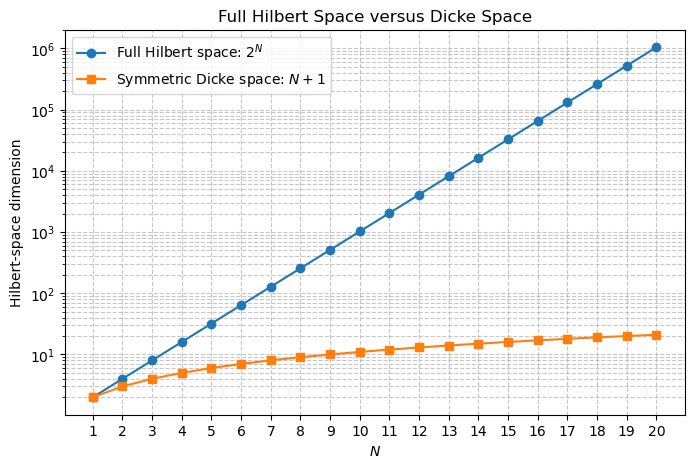

In [7]:

N_values = np.arange(1, 21)
full_dimensions = 2**N_values
dicke_dimensions = N_values + 1

plt.figure(figsize=(8, 5))
plt.semilogy(N_values,full_dimensions, "o-", label=r"Full Hilbert space: $2^N$")
plt.semilogy( N_values, dicke_dimensions, "s-", label=r"Symmetric Dicke space: $N+1$")

plt.xlabel("$N$") # Number of spins
plt.ylabel("Hilbert-space dimension")
plt.title("Full Hilbert Space versus Dicke Space") # Full Hilbert Space versus Symmetric Dicke Space
plt.xticks(N_values)
plt.grid(True, which="both", linestyle="--", alpha=0.7)
plt.legend()
plt.show()

## Interpretation

The graph shows that the dimension of the full Hilbert space, $2^N$, increases exponentially with the number of spins. In contrast, the dimension of the symmetric Dicke space, $N+1$, increases only linearly.

Therefore, using Dicke states can significantly reduce the required computational memory and calculation time. For example, at $N=20$, the full Hilbert space contains $2^{20}=1,048,576$ states, whereas the symmetric Dicke space contains only $21$ states.

However, this reduction is valid only when the Hamiltonian and the initial state have permutation symmetry. Under this condition, Dicke states provide a computationally efficient basis for studying collective spin models such as the all-to-all Ising model and the Lipkin–Meshkov–Glick model.

## Collective Spin Operators(Si) and the Ising Hamiltonian

S: collective spin of all \(N\) qubits.

### 1. Collective spin operators
The collective spin operator in direction $\alpha \in \{x,y,z\}$ is $S_\alpha = \sum_{i=1}^{N}s_\alpha^{(i)} = \frac{1}{2}\sum_{i=1}^{N}\sigma_\alpha^{(i)}$, giving:
$$S_x=\frac{1}{2}\sum_{i=1}^{N}\sigma_x^{(i)}, \qquad S_y=\frac{1}{2}\sum_{i=1}^{N}\sigma_y^{(i)}, \qquad S_z=\frac{1}{2}\sum_{i=1}^{N}\sigma_z^{(i)}$$

### 2. Raising and lowering operators
Ladder operators adjust excitation numbers by $\pm 1$:
$$S_\pm = S_x \pm iS_y$$

### 3. Interaction identity
Expanding $S_z^2 = \left(\frac{1}{2}\sum_i\sigma_z^{(i)}\right)\left(\frac{1}{2}\sum_j\sigma_z^{(j)}\right) = \frac{1}{4}\sum_i \left(\sigma_z^{(i)}\right)^2 + \frac{1}{4}\sum_{i\neq j} \sigma_z^{(i)}\sigma_z^{(j)}$. Since $\left(\sigma_z^{(i)}\right)^2=I$, the first term is $\frac{N}{4}I$, yielding:
$$\sum_{i\neq j} \sigma_z^{(i)}\sigma_z^{(j)} = 4S_z^2-NI$$

### 4. All-to-all Ising Hamiltonian
Substituting $\sum_{i\neq j} \sigma_z^{(i)}\sigma_z^{(j)} = 4S_z^2-NI$ and $\sum_i\sigma_x^{(i)}=2S_x$ into $H = J\sum_{i\neq j} \sigma_z^{(i)}\sigma_z^{(j)} + \Omega\sum_i\sigma_x^{(i)}$ gives:
$$H = 4JS_z^2 + 2\Omega S_x - JNI \;\to\; H = 4JS_z^2 + 2\Omega S_x$$
*(The constant energy shift $-JNI$ only adds a global phase and is typically dropped).*

### 5. Action on Dicke states
In the symmetric Dicke basis $|D_k^N\rangle$:
* $S_z|D_k^N\rangle = \left(k-\frac{N}{2}\right)|D_k^N\rangle$
* $S_+|D_k^N\rangle = \sqrt{(N-k)(k+1)}\,|D_{k+1}^N\rangle$
* $S_-|D_k^N\rangle = \sqrt{k(N-k+1)}\,|D_{k-1}^N\rangle$

### 6. Reduced Dicke-space representation
Restricting operators to the symmetric Dicke subspace reduces matrix sizes from $2^N \times 2^N$ to $(N+1) \times (N+1)$, enabling efficient numerical construction.

### Important summation convention
* **All pairs counted twice ($\sum_{i\neq j}$):** $\sum_{i\neq j}\sigma_z^{(i)}\sigma_z^{(j)} = 4S_z^2-NI \implies H = 4JS_z^2 + 2\Omega S_x - JNI$
* **Distinct pairs counted once ($\sum_{i<j}$):** $\sum_{i<j}\sigma_z^{(i)}\sigma_z^{(j)} = 2S_z^2-\frac{N}{2}I \implies H = 2JS_z^2 + 2\Omega S_x - \frac{JN}{2}I$

In [8]:
Sx = im.operators.collective_spin(2, "x")
Sy = im.operators.collective_spin(2, "y")
Sz = im.operators.collective_spin(2, "z")

print("Sx =\n", Sx)
print("Sy =\n", Sy)
print("Sz =\n", Sz) 
print()
print("Shape of Sx:", Sx.shape)
print("Shape of Sy:", Sy.shape)
print("Shape of Sz:", Sz.shape)

Sx =
 [[0. +0.j 0.5+0.j 0.5+0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0.5+0.j 0.5+0.j 0. +0.j]]
Sy =
 [[0.+0.j  0.-0.5j 0.-0.5j 0.+0.j ]
 [0.+0.5j 0.+0.j  0.+0.j  0.-0.5j]
 [0.+0.5j 0.+0.j  0.+0.j  0.-0.5j]
 [0.+0.j  0.+0.5j 0.+0.5j 0.+0.j ]]
Sz =
 [[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]]

Shape of Sx: (4, 4)
Shape of Sy: (4, 4)
Shape of Sz: (4, 4)


In [9]:
print(np.allclose(Sx.conj().T, Sx))
print(np.allclose(Sy.conj().T, Sy))
print(np.allclose(Sz.conj().T, Sz))

True
True
True


In [10]:
print(np.allclose(im.operators.commutator(Sx, Sy), 1j * Sz))
print(np.allclose(im.operators.commutator(Sy, Sz), 1j * Sx))
print(np.allclose(im.operators.commutator(Sz, Sx), 1j * Sy))

True
True
True


### Verification of Collective Spin Operators

Numerical results confirm $S_x, S_y, S_z$ are Hermitian ($S_\alpha^\dagger = S_\alpha$) and satisfy standard angular-momentum commutation relations:
$$[S_x, S_y] = iS_z, \qquad [S_y, S_z] = iS_x, \qquad [S_z, S_x] = iS_y$$
The constructed matrices correctly represent collective spin operators in the full Hilbert space.

In [11]:
N = 3

Sx_D, Sy_D, Sz_D, S_plus_D, S_minus_D = (im.operators.collective_spin_dicke(N))

print("Sx:\n", Sx_D)
print()
print("Sy:\n", Sy_D)
print()
print("Sz:\n", Sz_D)
print()

print("[Sx, Sy] = iSz:", np.allclose(im.operators.commutator(Sx_D, Sy_D), 1j * Sz_D ))
print("[Sy, Sz] = iSx:", np.allclose(im.operators.commutator(Sy_D, Sz_D), 1j * Sx_D  ))
print("[Sz, Sx] = iSy:", np.allclose(im.operators.commutator(Sz_D, Sx_D), 1j * Sy_D))
print("S+ dagger = S-:",np.allclose(S_plus_D.conj().T, S_minus_D))

Sx:
 [[0.       +0.j 0.8660254+0.j 0.       +0.j 0.       +0.j]
 [0.8660254+0.j 0.       +0.j 1.       +0.j 0.       +0.j]
 [0.       +0.j 1.       +0.j 0.       +0.j 0.8660254+0.j]
 [0.       +0.j 0.       +0.j 0.8660254+0.j 0.       +0.j]]

Sy:
 [[0.+0.j        0.-0.8660254j 0.+0.j        0.+0.j       ]
 [0.+0.8660254j 0.+0.j        0.-1.j        0.+0.j       ]
 [0.+0.j        0.+1.j        0.+0.j        0.-0.8660254j]
 [0.+0.j        0.+0.j        0.+0.8660254j 0.+0.j       ]]

Sz:
 [[ 1.5+0.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0.5+0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j -0.5+0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j -1.5+0.j]]

[Sx, Sy] = iSz: True
[Sy, Sz] = iSx: True
[Sz, Sx] = iSy: True
S+ dagger = S-: True


## Collective Operators in the Dicke Basis

For a permutation-symmetric system, collective spin operators can be represented in the Dicke basis

$$
\{|0\rangle,|1\rangle,\ldots,|N\rangle\}.
$$

This reduces the matrix dimension from

$$
2^N\times2^N
$$

to

$$
(N+1)\times(N+1).
$$

### Convention used in the lecture

In this section, $k$ counts the number of spins in state $|0\rangle$:

$$
k=\text{number of zeros},
\qquad
N-k=\text{number of ones}.
$$

Therefore,

$$
|N\rangle=|00\cdots0\rangle
$$

and

$$
|0\rangle=|11\cdots1\rangle.
$$

### Diagonal action of $S_z$

Because

$$
\sigma_z|0\rangle=|0\rangle,
\qquad
\sigma_z|1\rangle=-|1\rangle,
$$

a state containing $k$ zeros and $N-k$ ones satisfies

$$
S_z|k\rangle
=
\frac12\left[k-(N-k)\right]|k\rangle.
$$

Therefore,

$$
S_z|k\rangle
=
\left(k-\frac N2\right)|k\rangle.
$$

In the ordered basis

$$
\{|0\rangle,|1\rangle,\ldots,|N\rangle\},
$$

the matrix is

$$
S_z=
\operatorname{diag}
\left(
-\frac N2,
-\frac N2+1,
\ldots,
\frac N2
\right).
$$

### Collective ladder operators

The raising operator converts one $|1\rangle$ into $|0\rangle$. It therefore increases the number of zeros from $k$ to $k+1$:

$$
S_+|k\rangle
=
\sqrt{(N-k)(k+1)}
\,|k+1\rangle.
$$

The lowering operator converts one $|0\rangle$ into $|1\rangle$. It therefore decreases the number of zeros from $k$ to $k-1$:

$$
S_-|k\rangle
=
\sqrt{k(N-k+1)}
\,|k-1\rangle.
$$

### Connection with angular-momentum notation

The Dicke state $|k\rangle$ corresponds to

$$
|S,M\rangle,
$$

where

$$
S=\frac N2,
\qquad
M=k-\frac N2.
$$

The standard angular-momentum relation is

$$
S_+|S,M\rangle
=
\sqrt{S(S+1)-M(M+1)}
\,|S,M+1\rangle.
$$

Substituting

$$
S=\frac N2,
\qquad
M=k-\frac N2
$$

gives

$$
S_+|k\rangle
=
\sqrt{(N-k)(k+1)}
\,|k+1\rangle.
$$

Thus, the two expressions are equivalent.

### Cartesian components

The Cartesian collective-spin operators are

$$
S_x=\frac{S_++S_-}{2},
\qquad
S_y=\frac{S_+-S_-}{2i}.
$$

Because $S_+$ and $S_-$ connect only neighbouring Dicke states, $S_x$ and $S_y$ are tridiagonal in the Dicke basis.

In [18]:

Sx, Sy, Sz, S_plus, S_minus = (im.operators.collective_spin_dicke(N))

print("Sz =")
print(Sz.real)
print()

print("S+ =")
print(np.round(S_plus.real, 3))
print()

print("S- =")
print(np.round(S_minus.real, 3))
print()

print("Sx =")
print(np.round(Sx.real, 3))

Sz =
[[ 1.5  0.   0.   0. ]
 [ 0.   0.5  0.   0. ]
 [ 0.   0.  -0.5  0. ]
 [ 0.   0.   0.  -1.5]]

S+ =
[[0.    1.732 0.    0.   ]
 [0.    0.    2.    0.   ]
 [0.    0.    0.    1.732]
 [0.    0.    0.    0.   ]]

S- =
[[0.    0.    0.    0.   ]
 [1.732 0.    0.    0.   ]
 [0.    2.    0.    0.   ]
 [0.    0.    1.732 0.   ]]

Sx =
[[0.    0.866 0.    0.   ]
 [0.866 0.    1.    0.   ]
 [0.    1.    0.    0.866]
 [0.    0.    0.866 0.   ]]


In [28]:
k_0 = 1

# Vector representing |k=1> in the Dicke basis
ket_k = np.zeros(N + 1, dtype=complex)
ket_k[k_0] = 1

result_plus = S_plus @ ket_k
result_minus = S_minus@ ket_k

print("S+|0> =", result_plus.real)
print("S-|0> =", result_minus.real)

S+|0> = [1.73205081 0.         0.         0.        ]
S-|0> = [0. 0. 2. 0.]


In [21]:
k_1 = 1

# Vector representing |k=1> in the Dicke basis
ket_k = np.zeros(N + 1, dtype=complex)
ket_k[k_1] = 1

result_plus = S_plus @ ket_k
result_minus = S_minus@ ket_k

print("S+|1> =", result_plus.real)
print("S-|1> =", result_minus.real)

S+|1> = [1.73205081 0.         0.         0.        ]
S-|1> = [0. 0. 2. 0.]


In [26]:
k_2 = 2

# Vector representing |D_2^N> in the Dicke basis
ket_k = np.zeros(N + 1, dtype=complex)
ket_k[k_2] = 1

result_plus = S_plus @ ket_k
result_minus = S_minus @ ket_k

print("S+|2> =", result_plus.real)
print("S-|2> =", result_minus.real)

S+|2> = [0. 2. 0. 0.]
S-|2> = [0.         0.         0.         1.73205081]


In [27]:
k_3 = 3

# Vector representing |D_2^N> in the Dicke basis
ket_k = np.zeros(N + 1, dtype=complex)
ket_k[k_3] = 1

result_plus = S_plus @ ket_k
result_minus = S_minus @ ket_k

print("S+|3> =", result_plus.real)
print("S-|3> =", result_minus.real)

S+|3> = [0.         0.         1.73205081 0.        ]
S-|3> = [0. 0. 0. 0.]
